In [5]:
from langchain_openrouter import ChatOpenRouter
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.postgres import PostgresSaver
from langchain_core.messages.utils import trim_messages,count_tokens_approximately
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import RemoveMessage


In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenRouter(
    model="openai/gpt-oss-20b:free",
    temperature=0
)

In [6]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [7]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [8]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

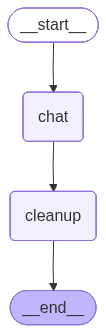

In [9]:
graph = builder.compile(checkpointer=InMemorySaver())
graph

In [10]:
config = {"configurable": {"thread_id": "t1"}}

In [11]:
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Subham"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

Failed to get info from https://api.smith.langchain.com: LangSmithConnectionError('Connection error caused failure to GET /info in LangSmith API. Please confirm your internet connection. ConnectTimeout(MaxRetryError("HTTPSConnectionPool(host=\'api.smith.langchain.com\', port=443): Max retries exceeded with url: /info (Caused by ConnectTimeoutError(<HTTPSConnection(host=\'api.smith.langchain.com\', port=443) at 0x15e0483a800>, \'Connection to api.smith.langchain.com timed out. (connect timeout=10.0)\'))"))\nContent-Length: None\nAPI Key: lsv2_********************************************b4')
Run compression is not enabled. Please update to the latest version of LangSmith. Falling back to regular multipart ingestion.
Failed to multipart ingest runs: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectTimeout(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max 

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='63c38ee9-9f97-45dd-8414-2cb6bea22a44'),
  AIMessage(content='## LangChain – The “Swiss Army Knife” for LLM‑Powered Applications\n\n> **TL;DR**  \n> LangChain is a Python framework that lets you build, test, and deploy applications that *talk to* large language models (LLMs) in a structured, composable way.  \n> Think of it as a toolkit that turns raw LLM calls into **pipelines** of prompts, memory, tools, and logic, all while keeping your code clean and testable.\n\n---\n\n### 1. Why LangChain Exists\n\n| Problem | Traditional Approach | LangChain Solution |\n|---------|----------------------|--------------------|\n| **LLM calls are “black boxes”** | You write a single prompt, call the API, get a string. | You wrap the call in a **Chain** that can be reused, tested, and composed. |\n| **Hard to keep context** | You manually stitch together conversation history. | Built‑in **Memory** 

In [12]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
